### Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df = pd.read_csv('country_wise_latest.csv')

display(df.head())

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


## 1. Data Cleaning

In [2]:
# Check missing values
print("Missing values:")
print(df.isnull().sum().sum())

df = df.dropna().drop_duplicates()

# New column: Active Cases Ratio (%)
df['Active Cases Ratio (%)'] = (df['Active'] / df['Confirmed']) * 100

print(f"Final shape: {df.shape}")
display(df.head())

Missing values:
0
Final shape: (187, 16)


,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region,Active Cases Ratio (%)
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean,27.013761
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe,40.799180
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa,28.502485
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe,5.733186
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa,70.210526


## 2. Summary Statistics & Correlation

In [3]:
display(df[['Confirmed', 'Deaths', 'Recovered', 'Active']].describe())

print("\nMode values:")
print(df[['Confirmed', 'Deaths', 'Recovered', 'Active']].mode().iloc[0])

,Confirmed,Deaths,Recovered,Active
count,1.870000e+02,187.000000,1.870000e+02,1.870000e+02
mean,8.813094e+04,3497.518717,5.063148e+04,3.400194e+04
std,3.833187e+05,14100.002482,1.901882e+05,2.133262e+05
min,1.000000e+01,0.000000,0.000000e+00,0.000000e+00
25%,1.114000e+03,18.500000,6.265000e+02,1.415000e+02
50%,5.059000e+03,108.000000,2.815000e+03,1.600000e+03
75%,4.046050e+04,734.000000,2.260600e+04,9.149000e+03
max,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06



Mode values:
Confirmed    24.0
Deaths        0.0
Recovered     0.0
Active        0.0
Name: 0, dtype: float64


### Correlation Heatmap

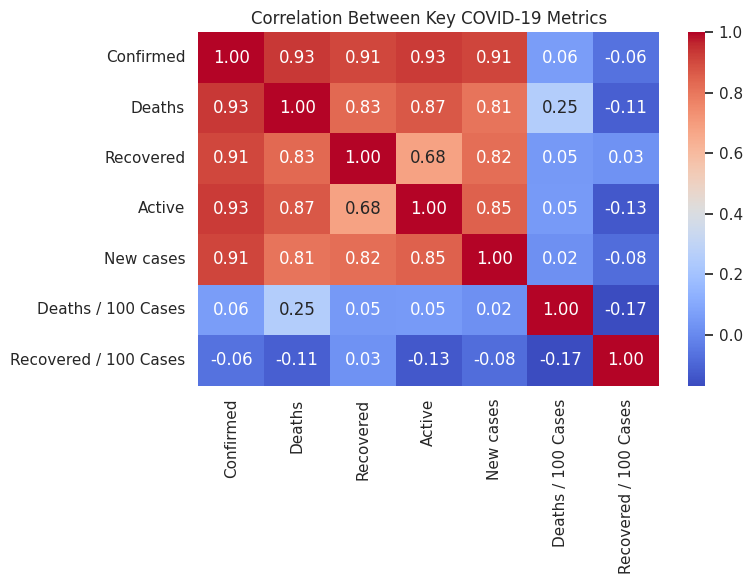

In [4]:
num_cols = ['Confirmed', 'Deaths', 'Recovered', 'Active', 'New cases',
            'Deaths / 100 Cases', 'Recovered / 100 Cases']

plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Key COVID-19 Metrics')
plt.tight_layout()
plt.show()

## 3. Top 5 Impacted Countries

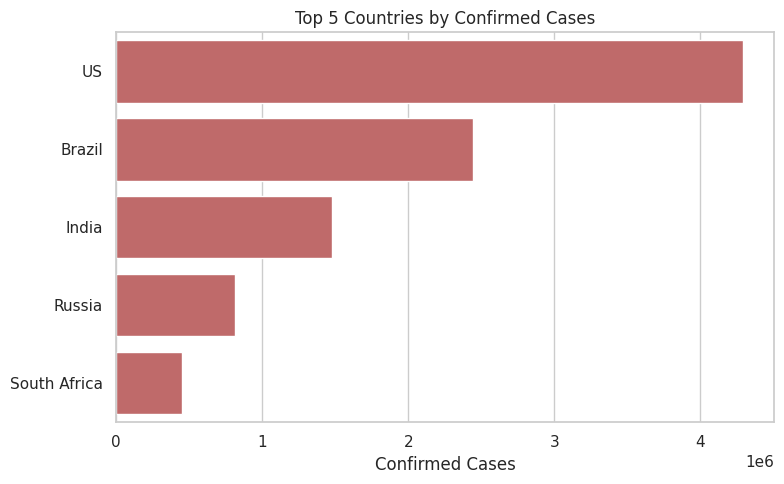

In [5]:
top5 = df.nlargest(5, 'Confirmed')[['Country/Region', 'Confirmed']]

plt.figure(figsize=(8, 5))
sns.barplot(x='Confirmed', y='Country/Region', data=top5, color='indianred')
plt.title('Top 5 Countries by Confirmed Cases')
plt.xlabel('Confirmed Cases')
plt.ylabel('')
plt.tight_layout()
plt.show()

## 4. WHO Regional Insights

,Confirmed,Deaths,Recovered
WHO Region,,,
Americas,8839286,342732,4468616
Europe,3299523,211144,1993723
South-East Asia,1835297,41349,1156933
Eastern Mediterranean,1490744,38339,1201400
Africa,723207,12223,440645
Western Pacific,292428,8249,206770


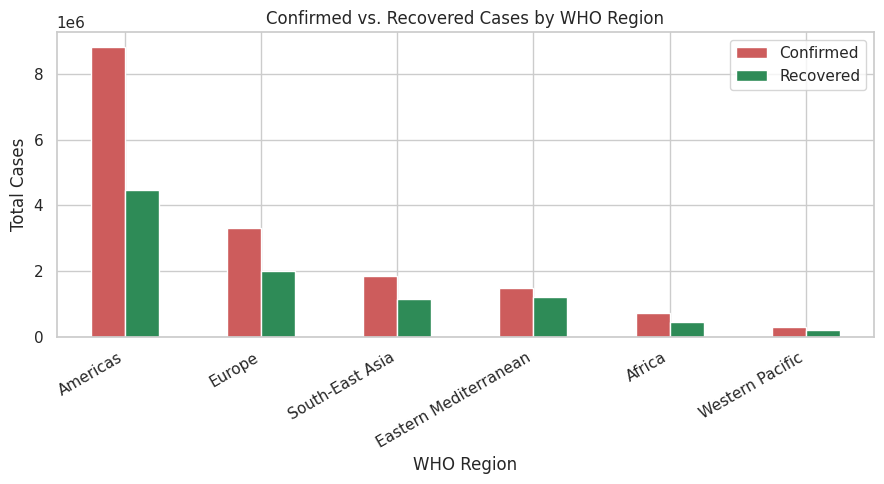

In [6]:
region_summary = df.groupby('WHO Region')[['Confirmed', 'Deaths', 'Recovered']].sum().sort_values('Confirmed', ascending=False)
display(region_summary)

region_summary[['Confirmed', 'Recovered']].plot(kind='bar', figsize=(9, 5), color=['indianred', 'seagreen'])
plt.title('Confirmed vs. Recovered Cases by WHO Region')
plt.xlabel('WHO Region')
plt.ylabel('Total Cases')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 5. Case Fatality Rate Distribution

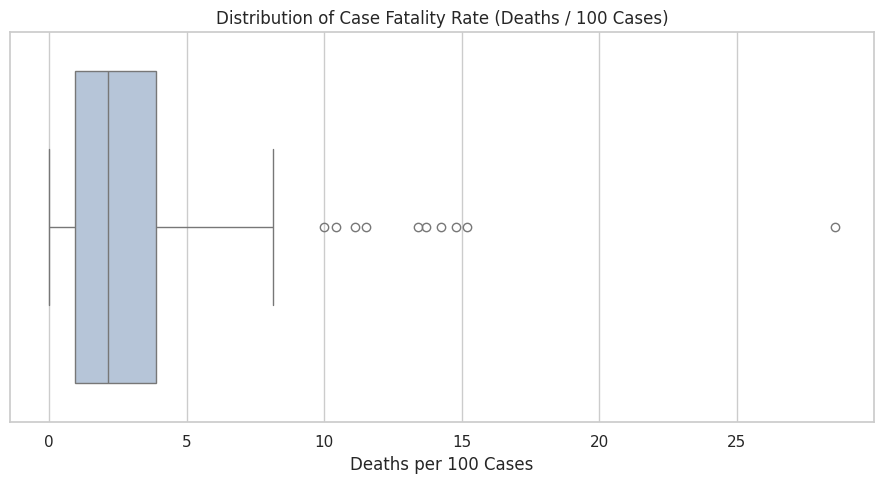

Countries with unusually high fatality rates:


,Country/Region,Deaths / 100 Cases
184,Yemen,28.56
177,United Kingdom,15.19
16,Belgium,14.79
85,Italy,14.26
61,France,13.71
77,Hungary,13.40
120,Netherlands,11.53
111,Mexico,11.13
157,Spain,10.44
183,Western Sahara,10.00


In [7]:
plt.figure(figsize=(9, 5))
sns.boxplot(x=df['Deaths / 100 Cases'], color='lightsteelblue')
plt.title('Distribution of Case Fatality Rate (Deaths / 100 Cases)')
plt.xlabel('Deaths per 100 Cases')
plt.tight_layout()
plt.show()

outliers = df[df['Deaths / 100 Cases'] > df['Deaths / 100 Cases'].quantile(0.95)][['Country/Region', 'Deaths / 100 Cases']]
print("Countries with unusually high fatality rates:")
display(outliers.sort_values('Deaths / 100 Cases', ascending=False))

## 6. Active Cases vs. New Cases

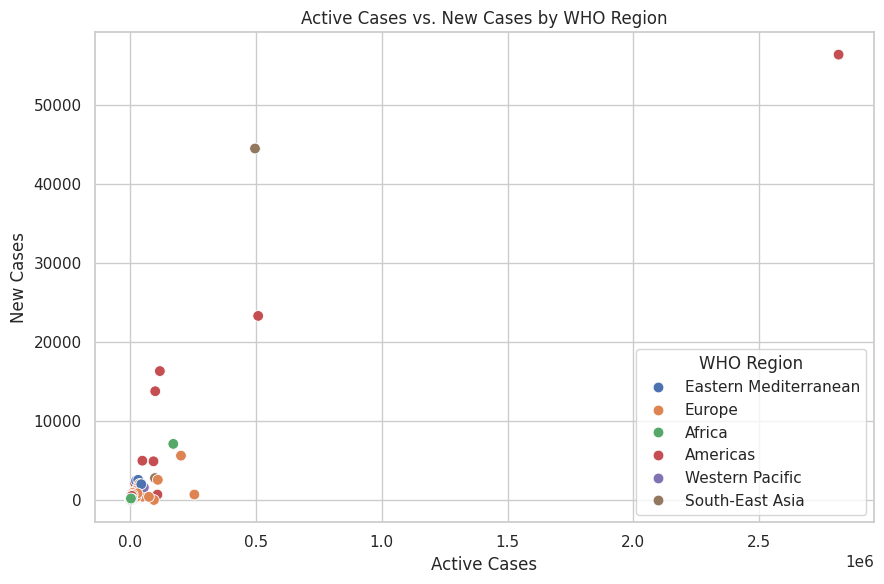

In [8]:
plt.figure(figsize=(9, 6))
sns.scatterplot(x='Active', y='New cases', hue='WHO Region', data=df, s=60)
plt.title('Active Cases vs. New Cases by WHO Region')
plt.xlabel('Active Cases')
plt.ylabel('New Cases')
plt.tight_layout()
plt.show()